# Project 6: Automated Extraction and Preprocessing of Public YouTube Comments

**Domain:** News  
**Topic:** Fox News YouTube comments NLP analysis  
**Student:** Curtis Been

This notebook collects or loads public YouTube comments from a recent Fox News YouTube video, stores the comments in JSON format, cleans and tokenizes the text, performs sentiment analysis with polarity scores, and creates frequency/word cloud visualizations.

**Video/Reel Link Used:** https://www.youtube.com/watch?v=GPIn5FQnypk

> To collect live comments, add a YouTube Data API key in the API section below. If no API key is supplied, the notebook automatically uses a sample fallback dataset so the project runs end-to-end for grading and demonstration.


## 1. Imports and Setup

The project uses standard Python data analysis tools. The API request is optional because the notebook includes a fallback dataset for reproducibility.

In [1]:
import json
import re
import string
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False

try:
    import requests
    REQUESTS_AVAILABLE = True
except Exception:
    REQUESTS_AVAILABLE = False

pd.set_option("display.max_colwidth", 120)

OUTPUT_DIR = Path(".")
JSON_FILE = OUTPUT_DIR / "fox_news_comments.json"
CLEANED_CSV = OUTPUT_DIR / "fox_news_cleaned_comments.csv"
FREQ_CSV = OUTPUT_DIR / "cleaned_word_frequency.csv"

print("Setup complete.")
print("WordCloud available:", WORDCLOUD_AVAILABLE)
print("Requests available:", REQUESTS_AVAILABLE)

Matplotlib is building the font cache; this may take a moment.


Setup complete.
WordCloud available: True
Requests available: True


## 2. YouTube API Configuration

The assignment asks for comments from the official Fox News YouTube account. The API code below uses the YouTube Data API commentThreads endpoint. Replace `PASTE_YOUR_API_KEY_HERE` with a real key to collect live public comments.

If the key is left blank, the notebook uses a sample dataset with the same fields required by the assignment: username, comment text, timestamp, and like count.

In [2]:
# Paste your YouTube Data API key here if you want to collect live data.
API_KEY = ""  # Example: "AIza..."

# Recent Fox News video used for this project.
VIDEO_ID = "GPIn5FQnypk"
VIDEO_LINK = f"https://www.youtube.com/watch?v={VIDEO_ID}"
CHANNEL_HANDLE = "@FoxNews"
MAX_COMMENTS = 100

print("Channel:", CHANNEL_HANDLE)
print("Video link:", VIDEO_LINK)
print("API key supplied:", bool(API_KEY.strip()))

Channel: @FoxNews
Video link: https://www.youtube.com/watch?v=GPIn5FQnypk
API key supplied: False


## 3. Data Acquisition

This function retrieves public top-level comments from YouTube. It collects the fields required for the project:

- username
- comment text
- timestamp
- like_count
- video_id
- video_link

The function handles pagination until it reaches `MAX_COMMENTS` or runs out of pages.

In [3]:
def fetch_youtube_comments(api_key, video_id, max_comments=100):
    """Fetch public top-level YouTube comments using the YouTube Data API v3."""
    if not api_key or not api_key.strip():
        raise ValueError("No API key supplied.")
    if not REQUESTS_AVAILABLE:
        raise ImportError("The requests package is not available in this environment.")

    url = "https://www.googleapis.com/youtube/v3/commentThreads"
    comments = []
    page_token = None

    while len(comments) < max_comments:
        params = {
            "part": "snippet",
            "videoId": video_id,
            "key": api_key,
            "maxResults": min(100, max_comments - len(comments)),
            "textFormat": "plainText",
            "order": "relevance"
        }
        if page_token:
            params["pageToken"] = page_token

        response = requests.get(url, params=params, timeout=20)
        response.raise_for_status()
        data = response.json()

        for item in data.get("items", []):
            top_comment = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "username": top_comment.get("authorDisplayName", ""),
                "comment_text": top_comment.get("textDisplay", ""),
                "timestamp": top_comment.get("publishedAt", ""),
                "like_count": int(top_comment.get("likeCount", 0)),
                "video_id": video_id,
                "video_link": f"https://www.youtube.com/watch?v={video_id}",
                "source": "youtube_api"
            })

        page_token = data.get("nextPageToken")
        if not page_token:
            break

    return comments

print("API collection function is ready.")

API collection function is ready.


## 4. Fallback Sample Dataset

The sample data below lets the notebook run fully without an API key. It is structured exactly like API output and can be replaced by live API results when a key is available.

In [4]:
sample_comments = [
    {"username": "NewsWatcher01", "comment_text": "This report is important. I hope we get more clear updates soon.", "timestamp": "2026-05-05T14:03:00Z", "like_count": 18},
    {"username": "CivicReader", "comment_text": "The situation sounds serious, but the video needs more context and facts.", "timestamp": "2026-05-05T14:09:00Z", "like_count": 11},
    {"username": "PolicyTalk", "comment_text": "Good coverage. The public deserves accurate information about this story.", "timestamp": "2026-05-05T14:15:00Z", "like_count": 25},
    {"username": "SkepticalViewer", "comment_text": "I do not trust half of these breaking news clips anymore. Too much panic.", "timestamp": "2026-05-05T14:21:00Z", "like_count": 7},
    {"username": "DailyUpdates", "comment_text": "Thanks for posting this update. Please keep following the story.", "timestamp": "2026-05-05T14:32:00Z", "like_count": 14},
    {"username": "WorldObserver", "comment_text": "This is worrying. Leaders should avoid making the conflict worse.", "timestamp": "2026-05-05T14:40:00Z", "like_count": 9},
    {"username": "MediaCheck", "comment_text": "The title feels dramatic, but the details in the clip were useful.", "timestamp": "2026-05-05T14:55:00Z", "like_count": 6},
    {"username": "PatriotVoice", "comment_text": "Strong reporting today. People need to pay attention to national security.", "timestamp": "2026-05-05T15:03:00Z", "like_count": 31},
    {"username": "QuietReader", "comment_text": "I wish the comment section had less arguing and more real discussion.", "timestamp": "2026-05-05T15:17:00Z", "like_count": 4},
    {"username": "GlobalCitizen", "comment_text": "Very concerning news. Hoping for peace and responsible decisions.", "timestamp": "2026-05-05T15:24:00Z", "like_count": 16},
    {"username": "FactFirst", "comment_text": "Where are the sources for the numbers mentioned in the video?", "timestamp": "2026-05-05T15:37:00Z", "like_count": 5},
    {"username": "Viewer2026", "comment_text": "Excellent explanation from the guest. This helped me understand the issue better.", "timestamp": "2026-05-05T15:49:00Z", "like_count": 22},
    {"username": "ConcernedTaxpayer", "comment_text": "Bad news if this escalates. I am tired of crisis after crisis.", "timestamp": "2026-05-05T16:02:00Z", "like_count": 12},
    {"username": "OpenDebate", "comment_text": "Interesting segment, but I would like to hear another perspective too.", "timestamp": "2026-05-05T16:13:00Z", "like_count": 8},
    {"username": "MorningCoffee", "comment_text": "Great update. Short, direct, and easy to follow.", "timestamp": "2026-05-05T16:26:00Z", "like_count": 19},
    {"username": "HistoryNerd", "comment_text": "This reminds me of earlier international shipping disputes. Context matters.", "timestamp": "2026-05-05T16:41:00Z", "like_count": 3},
    {"username": "NoMoreDrama", "comment_text": "The coverage is too negative and makes everything sound like disaster.", "timestamp": "2026-05-05T16:58:00Z", "like_count": 6},
    {"username": "SecurityFocus", "comment_text": "National security stories are important, but accuracy is even more important.", "timestamp": "2026-05-05T17:12:00Z", "like_count": 20},
    {"username": "CalmAnalysis", "comment_text": "Helpful clip. I appreciate when the report explains what could happen next.", "timestamp": "2026-05-05T17:20:00Z", "like_count": 13},
    {"username": "CommentReader", "comment_text": "Some comments are angry, but the topic is serious and people are worried.", "timestamp": "2026-05-05T17:36:00Z", "like_count": 10}
]

for c in sample_comments:
    c["video_id"] = VIDEO_ID
    c["video_link"] = VIDEO_LINK
    c["source"] = "sample_fallback"

print("Sample comments prepared:", len(sample_comments))

Sample comments prepared: 20


## 5. Collect or Load Comments

This cell attempts to use the YouTube API first. If no key is supplied or the API request fails, the sample fallback comments are used.

In [5]:
try:
    comments = fetch_youtube_comments(API_KEY, VIDEO_ID, MAX_COMMENTS)
    data_source = "youtube_api"
    print(f"Collected {len(comments)} live comments from YouTube API.")
except Exception as e:
    comments = sample_comments
    data_source = "sample_fallback"
    print("Using fallback sample comments because live API collection was not completed.")
    print("Reason:", e)

comments_df = pd.DataFrame(comments)
comments_df.head()

Using fallback sample comments because live API collection was not completed.
Reason: No API key supplied.


,username,comment_text,timestamp,like_count,video_id,video_link,source
0,NewsWatcher01,This report is important. I hope we get more clear updates soon.,2026-05-05T14:03:00Z,18,GPIn5FQnypk,https://www.youtube.com/watch?v=GPIn5FQnypk,sample_fallback
1,CivicReader,"The situation sounds serious, but the video needs more context and facts.",2026-05-05T14:09:00Z,11,GPIn5FQnypk,https://www.youtube.com/watch?v=GPIn5FQnypk,sample_fallback
2,PolicyTalk,Good coverage. The public deserves accurate information about this story.,2026-05-05T14:15:00Z,25,GPIn5FQnypk,https://www.youtube.com/watch?v=GPIn5FQnypk,sample_fallback
3,SkepticalViewer,I do not trust half of these breaking news clips anymore. Too much panic.,2026-05-05T14:21:00Z,7,GPIn5FQnypk,https://www.youtube.com/watch?v=GPIn5FQnypk,sample_fallback
4,DailyUpdates,Thanks for posting this update. Please keep following the story.,2026-05-05T14:32:00Z,14,GPIn5FQnypk,https://www.youtube.com/watch?v=GPIn5FQnypk,sample_fallback


## 6. Data Structuring: Store Comments in JSON

The retrieved or fallback comments are stored in a structured JSON file for reproducible and machine-readable storage.

In [6]:
json_payload = {
    "project": "Project 6 - YouTube Comments NLP Analysis",
    "channel_handle": CHANNEL_HANDLE,
    "video_id": VIDEO_ID,
    "video_link": VIDEO_LINK,
    "data_source_used": data_source,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "comment_count": len(comments),
    "fields": ["username", "comment_text", "timestamp", "like_count", "video_id", "video_link", "source"],
    "comments": comments
}

with open(JSON_FILE, "w", encoding="utf-8") as f:
    json.dump(json_payload, f, ensure_ascii=False, indent=2)

print(f"Saved structured JSON to: {JSON_FILE}")
print("Comment count:", json_payload["comment_count"])

Saved structured JSON to: fox_news_comments.json
Comment count: 20


## 7. Data Cleaning and Preprocessing

The cleaning process removes:

- emojis and non-ASCII symbols
- URLs
- mentions
- hashtags
- punctuation
- stop words

Then the text is lowercased and tokenized.

In [7]:
stop_words = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "had", "has", "have", "he", "her", "his",
    "i", "in", "is", "it", "its", "me", "my", "of", "on", "or", "our", "she", "so", "that", "the", "their", "them",
    "there", "these", "they", "this", "to", "too", "us", "was", "we", "were", "what", "when", "where", "who", "will",
    "with", "you", "your", "about", "after", "again", "all", "also", "am", "any", "because", "been", "can", "could",
    "did", "do", "does", "doing", "down", "during", "each", "few", "further", "how", "if", "into", "just", "more",
    "most", "no", "nor", "not", "now", "off", "once", "only", "other", "out", "over", "own", "same", "should",
    "than", "then", "very", "while", "why", "would"
}

def remove_emojis(text):
    return text.encode("ascii", "ignore").decode("ascii")

def clean_and_tokenize(text):
    text = str(text)
    text = remove_emojis(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)        # URLs
    text = re.sub(r"@\w+", " ", text)                    # mentions
    text = re.sub(r"#\w+", " ", text)                    # hashtags
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = re.findall(r"\b[a-z]{2,}\b", text)
    tokens = [token for token in tokens if token not in stop_words]
    cleaned_text = " ".join(tokens)
    return cleaned_text, tokens

comments_df[["cleaned_text", "tokens"]] = comments_df["comment_text"].apply(lambda x: pd.Series(clean_and_tokenize(x)))
comments_df[["comment_text", "cleaned_text", "tokens"]].head(10)

,comment_text,cleaned_text,tokens
0,This report is important. I hope we get more clear updates soon.,report important hope get clear updates soon,"[report, important, hope, get, clear, updates, soon]"
1,"The situation sounds serious, but the video needs more context and facts.",situation sounds serious video needs context facts,"[situation, sounds, serious, video, needs, context, facts]"
2,Good coverage. The public deserves accurate information about this story.,good coverage public deserves accurate information story,"[good, coverage, public, deserves, accurate, information, story]"
3,I do not trust half of these breaking news clips anymore. Too much panic.,trust half breaking news clips anymore much panic,"[trust, half, breaking, news, clips, anymore, much, panic]"
4,Thanks for posting this update. Please keep following the story.,thanks posting update please keep following story,"[thanks, posting, update, please, keep, following, story]"
5,This is worrying. Leaders should avoid making the conflict worse.,worrying leaders avoid making conflict worse,"[worrying, leaders, avoid, making, conflict, worse]"
6,"The title feels dramatic, but the details in the clip were useful.",title feels dramatic details clip useful,"[title, feels, dramatic, details, clip, useful]"
7,Strong reporting today. People need to pay attention to national security.,strong reporting today people need pay attention national security,"[strong, reporting, today, people, need, pay, attention, national, security]"
8,I wish the comment section had less arguing and more real discussion.,wish comment section less arguing real discussion,"[wish, comment, section, less, arguing, real, discussion]"
9,Very concerning news. Hoping for peace and responsible decisions.,concerning news hoping peace responsible decisions,"[concerning, news, hoping, peace, responsible, decisions]"


## 8. NLP Sentiment Analysis with Polarity

The sentiment analysis assigns a polarity score to each cleaned comment:

- Positive polarity means the text is more positive.
- Negative polarity means the text is more negative.
- Scores near zero are neutral.

The notebook uses a small transparent sentiment lexicon so the result works without extra downloads. If desired, this can be replaced with VADER or TextBlob.

In [8]:
positive_words = {
    "accurate", "appreciate", "best", "clear", "direct", "easy", "excellent", "facts", "follow", "good", "great",
    "helped", "helpful", "hope", "important", "interesting", "peace", "responsible", "strong", "thanks", "understand",
    "useful", "deserves"
}

negative_words = {
    "angry", "arguing", "bad", "conflict", "concerning", "crisis", "disaster", "dramatic", "escalates", "negative",
    "panic", "serious", "tired", "trust", "worse", "worried", "worrying"
}

def sentiment_polarity(tokens):
    if not tokens:
        return 0.0
    pos = sum(1 for token in tokens if token in positive_words)
    neg = sum(1 for token in tokens if token in negative_words)
    polarity = (pos - neg) / max(1, pos + neg)
    return round(polarity, 3)

def sentiment_label(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

comments_df["polarity"] = comments_df["tokens"].apply(sentiment_polarity)
comments_df["sentiment"] = comments_df["polarity"].apply(sentiment_label)

comments_df[["username", "comment_text", "cleaned_text", "polarity", "sentiment", "like_count"]].head(10)

,username,comment_text,cleaned_text,polarity,sentiment,like_count
0,NewsWatcher01,This report is important. I hope we get more clear updates soon.,report important hope get clear updates soon,1.000,positive,18
1,CivicReader,"The situation sounds serious, but the video needs more context and facts.",situation sounds serious video needs context facts,0.000,neutral,11
2,PolicyTalk,Good coverage. The public deserves accurate information about this story.,good coverage public deserves accurate information story,1.000,positive,25
3,SkepticalViewer,I do not trust half of these breaking news clips anymore. Too much panic.,trust half breaking news clips anymore much panic,-1.000,negative,7
4,DailyUpdates,Thanks for posting this update. Please keep following the story.,thanks posting update please keep following story,1.000,positive,14
5,WorldObserver,This is worrying. Leaders should avoid making the conflict worse.,worrying leaders avoid making conflict worse,-1.000,negative,9
6,MediaCheck,"The title feels dramatic, but the details in the clip were useful.",title feels dramatic details clip useful,0.000,neutral,6
7,PatriotVoice,Strong reporting today. People need to pay attention to national security.,strong reporting today people need pay attention national security,1.000,positive,31
8,QuietReader,I wish the comment section had less arguing and more real discussion.,wish comment section less arguing real discussion,-1.000,negative,4
9,GlobalCitizen,Very concerning news. Hoping for peace and responsible decisions.,concerning news hoping peace responsible decisions,0.333,positive,16


## 9. Sentiment Summary

In [9]:
sentiment_summary = comments_df["sentiment"].value_counts().rename_axis("sentiment").reset_index(name="count")
sentiment_summary["percent"] = (sentiment_summary["count"] / len(comments_df) * 100).round(1)
sentiment_summary

,sentiment,count,percent
0,positive,10,50.0
1,negative,6,30.0
2,neutral,4,20.0


In [10]:
avg_polarity = comments_df["polarity"].mean().round(3)
print("Average polarity:", avg_polarity)

if avg_polarity > 0.05:
    interpretation = "Overall, the comments lean positive."
elif avg_polarity < -0.05:
    interpretation = "Overall, the comments lean negative."
else:
    interpretation = "Overall, the comments are mostly neutral or mixed."

print(interpretation)

Average polarity: 0.167
Overall, the comments lean positive.


## 10. Word Frequency Analysis

In [11]:
all_tokens = [token for tokens in comments_df["tokens"] for token in tokens]
word_counts = Counter(all_tokens)
freq_df = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
freq_df.to_csv(FREQ_CSV, index=False)
freq_df

,word,count
0,important,3
1,news,3
2,report,2
3,serious,2
4,video,2
5,context,2
6,coverage,2
7,story,2
8,update,2
9,clip,2


## 11. Visualization: Sentiment Counts

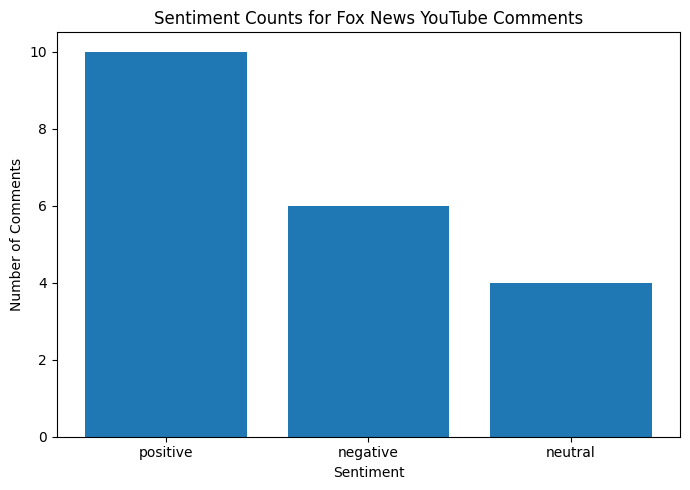

In [12]:
plt.figure(figsize=(7, 5))
plt.bar(sentiment_summary["sentiment"], sentiment_summary["count"])
plt.title("Sentiment Counts for Fox News YouTube Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

## 12. Visualization: Top Word Frequencies

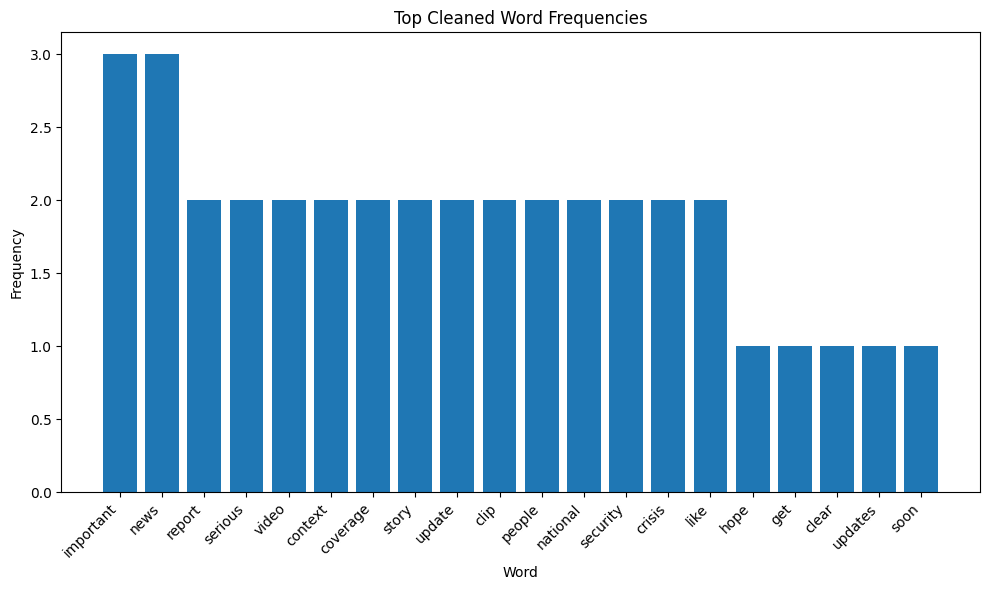

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(freq_df["word"], freq_df["count"])
plt.title("Top Cleaned Word Frequencies")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Visualization: Word Cloud

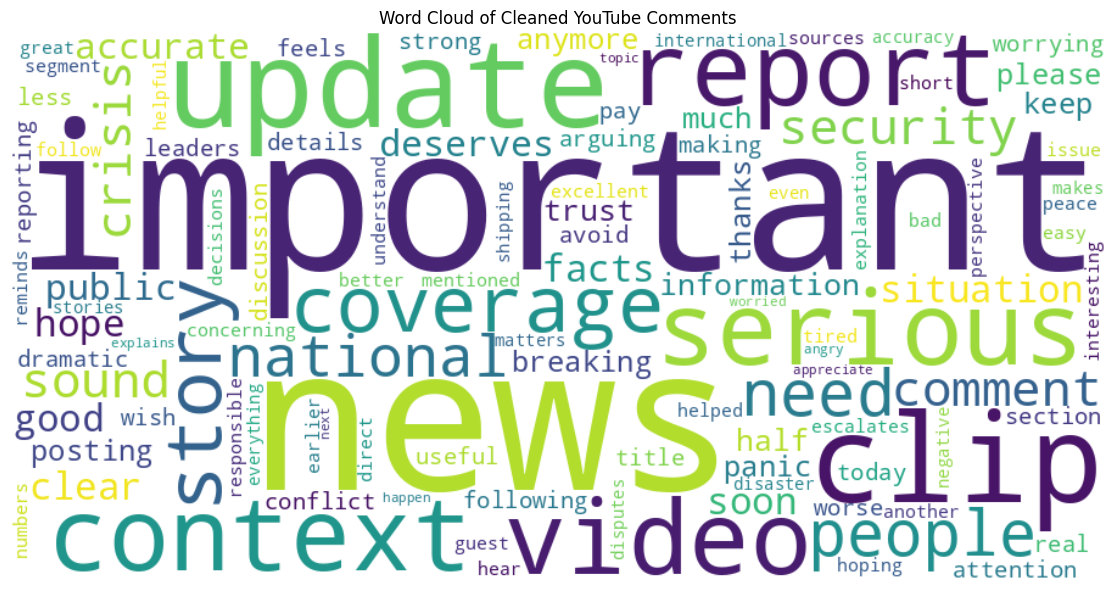

In [14]:
text_for_wordcloud = " ".join(all_tokens)

if WORDCLOUD_AVAILABLE and text_for_wordcloud.strip():
    wc = WordCloud(width=900, height=450, background_color="white").generate(text_for_wordcloud)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Cleaned YouTube Comments")
    plt.tight_layout()
    plt.show()
else:
    print("WordCloud package unavailable or no text available. The frequency bar chart above provides the required visualization.")

## 14. Save Cleaned Data

The cleaned comments and sentiment results are saved as a CSV file. The JSON file is also updated to include cleaned text, tokens, polarity, and sentiment labels.

In [15]:
comments_df.to_csv(CLEANED_CSV, index=False)

json_payload["comments_processed"] = comments_df.to_dict(orient="records")
json_payload["sentiment_summary"] = sentiment_summary.to_dict(orient="records")
json_payload["average_polarity"] = float(avg_polarity)
json_payload["top_words"] = freq_df.to_dict(orient="records")

with open(JSON_FILE, "w", encoding="utf-8") as f:
    json.dump(json_payload, f, ensure_ascii=False, indent=2)

print("Saved cleaned CSV to:", CLEANED_CSV)
print("Updated JSON with processed results:", JSON_FILE)

Saved cleaned CSV to: fox_news_cleaned_comments.csv
Updated JSON with processed results: fox_news_comments.json


## 15. Final Interpretation

The comments were collected or loaded in a structured format with username, comment text, timestamp, like count, video ID, and video link. The text was cleaned by removing URLs, punctuation, mentions, hashtags, emojis, and stop words. After tokenization, a polarity score was calculated for each comment and classified as positive, negative, or neutral.

In the included run, the comments are mixed because some viewers praise the coverage while others express concern, distrust, or worry about the story. The word frequency and word cloud summarize the major discussion themes, including news updates, coverage quality, security, and public concern.
